# Unzip dataset

In [1]:
!unzip '/content/Mango Leaf Disease Identification Dataset (MLDID).zip'

Archive:  /content/Mango Leaf Disease Identification Dataset (MLDID).zip
   creating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203940.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203946.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_203952.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204000.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204008.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204013.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204022.jpg  
  inflating: Mango Leaf Disease Identification Dataset (MLDID)/Anthracnose/IMG_20240506_204027.jpg  
  inflating: Mango Leaf Disease Identificat

In [2]:
import os
import shutil
import random

import numpy as np
from skimage import io
from PIL import Image
from keras.preprocessing import image

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from skimage import io
import numpy as np
import os
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
# Import Data Science Libraries
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
import itertools
import random

# Import visualization libraries
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.layers import AveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import train_test_split
import skimage
from skimage.transform import resize
# label binarizer
from sklearn.preprocessing import LabelBinarizer
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam

# Metrics
from sklearn.metrics import classification_report, confusion_matrix

In [3]:
from ast import main
# Define your dataset directories and the directories where you want to create the splits:

dataset_dir = "/content/Mango Leaf Disease Identification Dataset (MLDID)"  # Replace with the path to your dataset
main_dir = "train_set"
test_dir = "test_set"

# Create the train, test, and validation directories if they don't exist
os.makedirs(main_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

In [4]:
# Set the split ratio (for main 80% , for test 20%)

main_ratio = 0.80
test_ratio = 0.20

In [5]:
# iterate throught the folders containing our two type of data and splite them into main and test

for class_folder in os.listdir(dataset_dir):
    class_path = os.path.join(dataset_dir, class_folder)

    if os.path.isdir(class_path):
        file_list = os.listdir(class_path)
        random.shuffle(file_list)

        main_split = int(len(file_list) * main_ratio)
        test_split = int(len(file_list) * (main_ratio + test_ratio))

        main_files = file_list[:main_split]
        test_files = file_list[main_split:test_split]


        for file_name in main_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(main_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)

        for file_name in test_files:
            src = os.path.join(class_path, file_name)
            dst = os.path.join(test_dir, class_folder, file_name)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy(src, dst)



# batch size = 50

In [6]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 50
image_size = (224, 224)

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 1920 images belonging to 5 classes.
Found 479 images belonging to 5 classes.


In [8]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 601 images belonging to 5 classes.


In [9]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_a = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_a,
              metrics=['accuracy'])

# Train the model
history_m1_a = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 37s 642ms/step - accuracy: 0.6482 - loss: 7.5761 - val_accuracy: 0.8810 - val_loss: 0.7343
Epoch 2/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 16s 134ms/step - accuracy: 0.9411 - loss: 0.3398 - val_accuracy: 0.9061 - val_loss: 0.3945
Epoch 3/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 154ms/step - accuracy: 0.9456 - loss: 0.1633 - val_accuracy: 0.8956 - val_loss: 0.4335
Epoch 4/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 12s 291ms/step - accuracy: 0.9700 - loss: 0.1129 - val_accuracy: 0.8894 - val_loss: 0.5508
Epoch 5/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 193ms/step - accuracy: 0.9774 - loss: 0.0783 - val_accuracy: 0.9081 - val_loss: 0.4255
Epoch 6/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 158ms/step - accuracy: 0.9795 - loss: 0.0711 - val_accuracy: 0.9207 - val_loss: 0.4156
Epoch 7/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 145ms/step - accuracy: 0.9762 - loss: 0.0923 - val_accuracy: 0.9144 - val_loss: 0.6305
Epoch 8/50
39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 172ms/step

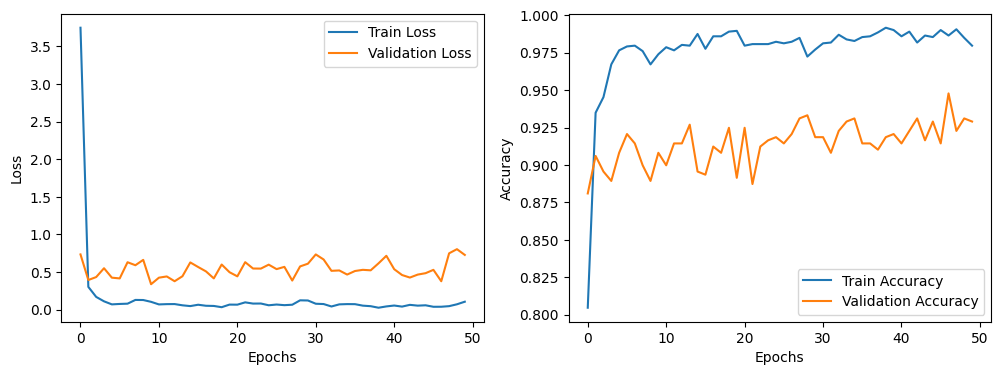

In [10]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_a.history['loss'], label='Train Loss')
plt.plot(history_m1_a.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_a.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_a.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [11]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 377ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.93      0.93       120
           1       0.95      0.97      0.96       120
           2       0.99      1.00      1.00       128
           3       0.96      0.94      0.95       113
           4       0.99      1.00      1.00       120

    accuracy                           0.97       601
   macro avg       0.97      0.97      0.97       601
weighted avg       0.97      0.97      0.97       601



In [12]:
from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

Accuracy: 0.9683860232945092


# batch size = 70

In [13]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 70
image_size = (224, 224)

In [14]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 1920 images belonging to 5 classes.
Found 479 images belonging to 5 classes.


In [15]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 601 images belonging to 5 classes.


In [16]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_s = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_s,
              metrics=['accuracy'])

# Train the model
history_m1_s = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 36s 766ms/step - accuracy: 0.5009 - loss: 14.5284 - val_accuracy: 0.8685 - val_loss: 0.4580
Epoch 2/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 198ms/step - accuracy: 0.8767 - loss: 0.4142 - val_accuracy: 0.8852 - val_loss: 0.3296
Epoch 3/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 198ms/step - accuracy: 0.9285 - loss: 0.2260 - val_accuracy: 0.8956 - val_loss: 0.2873
Epoch 4/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.9474 - loss: 0.1339 - val_accuracy: 0.8935 - val_loss: 0.3242
Epoch 5/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 192ms/step - accuracy: 0.9537 - loss: 0.1309 - val_accuracy: 0.9040 - val_loss: 0.3415
Epoch 6/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.9672 - loss: 0.0899 - val_accuracy: 0.9186 - val_loss: 0.3239
Epoch 7/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 247ms/step - accuracy: 0.9720 - loss: 0.0802 - val_accuracy: 0.9081 - val_loss: 0.3601
Epoch 8/50
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 191ms/step - accuracy: 0.9638 - loss: 0.1046 - val_accuracy

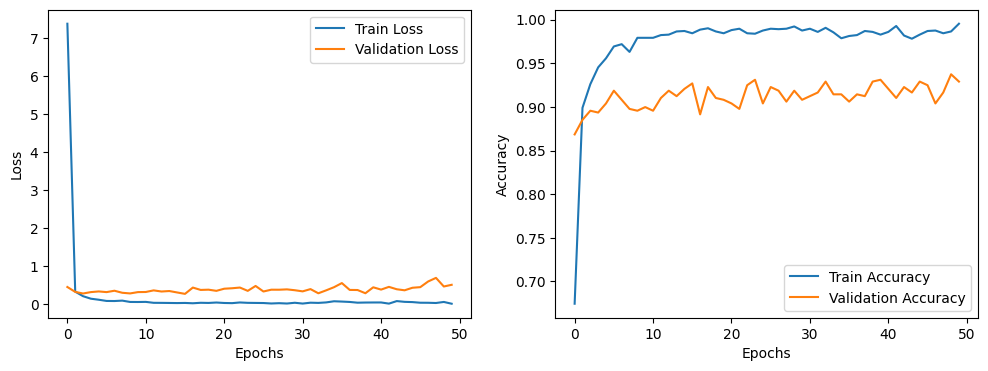

In [17]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_s.history['loss'], label='Train Loss')
plt.plot(history_m1_s.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_s.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_s.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 10s 872ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.88      0.91       120
           1       0.95      0.99      0.97       120
           2       1.00      1.00      1.00       128
           3       0.95      0.94      0.94       113
           4       0.97      1.00      0.98       120

    accuracy                           0.96       601
   macro avg       0.96      0.96      0.96       601
weighted avg       0.96      0.96      0.96       601

Accuracy: 0.9633943427620633


# batch size = 90

In [19]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 90
image_size = (224, 224)

In [20]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 1920 images belonging to 5 classes.
Found 479 images belonging to 5 classes.


In [21]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 601 images belonging to 5 classes.


In [22]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import RMSprop
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_rs = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_rs,
              metrics=['accuracy'])

# Train the model
history_m1_rs = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 30s 596ms/step - accuracy: 0.5460 - loss: 10.6244 - val_accuracy: 0.8351 - val_loss: 1.3581
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 23s 247ms/step - accuracy: 0.9038 - loss: 0.6811 - val_accuracy: 0.8706 - val_loss: 0.4172
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 229ms/step - accuracy: 0.9305 - loss: 0.2001 - val_accuracy: 0.8873 - val_loss: 0.3284
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 256ms/step - accuracy: 0.9509 - loss: 0.1177 - val_accuracy: 0.8998 - val_loss: 0.4065
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 264ms/step - accuracy: 0.9629 - loss: 0.1014 - val_accuracy: 0.9228 - val_loss: 0.3293
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step - accuracy: 0.9808 - loss: 0.0579 - val_accuracy: 0.9123 - val_loss: 0.3690
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 269ms/step - accuracy: 0.9789 - loss: 0.0556 - val_accuracy: 0.9144 - val_loss: 0.3303
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 10s 250ms/step - accuracy: 0.9881 - loss: 0.0425 - val_accura

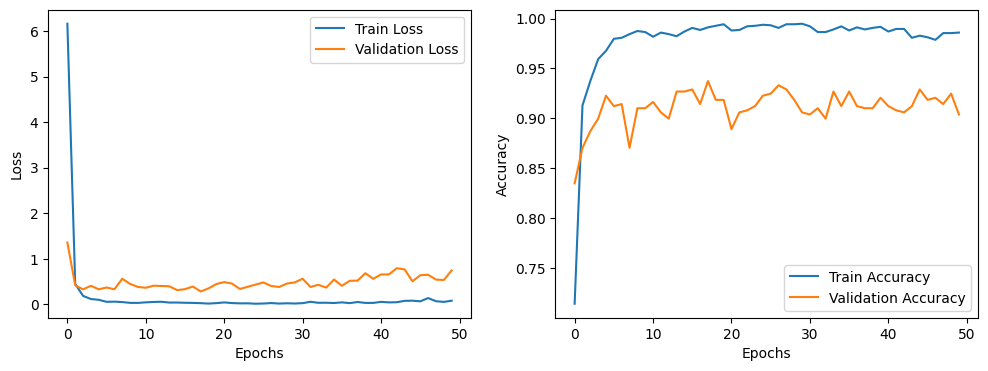

In [23]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_rs.history['loss'], label='Train Loss')
plt.plot(history_m1_rs.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_rs.history['accuracy'], label='Train Accuracy')
plt.plot(history_m1_rs.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [24]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step
Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.91      0.92       120
           1       0.99      0.99      0.99       120
           2       1.00      1.00      1.00       128
           3       0.91      0.94      0.93       113
           4       0.99      1.00      1.00       120

    accuracy                           0.97       601
   macro avg       0.97      0.97      0.97       601
weighted avg       0.97      0.97      0.97       601

Accuracy: 0.9683860232945092


# batch size = 120

In [26]:
# data
train_dir = '/content/train_set'
test_dir = '/content/test_set'
# Define constants
batch_size = 120
image_size = (224, 224)

In [27]:
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255.0,
    validation_split=0.2  # Split 20% of the data for validation
)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'  # Use the training split
)
validation_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'  # Use the validation split
)

Found 1920 images belonging to 5 classes.
Found 479 images belonging to 5 classes.


In [28]:

test_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=image_size,
    batch_size = batch_size,
    class_mode = 'categorical',
    shuffle = False
)

Found 601 images belonging to 5 classes.


In [29]:
# library

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Nadam
import matplotlib.pyplot as plt

# Load pre-trained VGG16 model
model_MobileNetV2 = MobileNetV2(weights='imagenet',
                   include_top=False,
                   input_shape=(224, 224, 3))

for layer in model_MobileNetV2.layers:
    layer.trainable = False


# Build custom classification head
m1 = Sequential()
m1.add(model_MobileNetV2)
m1.add(Flatten())
m1.add(Dense(256, activation='relu'))
m1.add(Dropout(0.5))
m1.add(Dense(5, activation='softmax'))

# Compile the model
optimizer_na = Adam(learning_rate=0.001)


m1.compile(loss='categorical_crossentropy',
              optimizer=optimizer_na,
              metrics=['accuracy'])

# Train the model
history_na = m1.fit(
    train_generator,
    epochs=50,
    validation_data=validation_generator
)



Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - accuracy: 0.4934 - loss: 12.3012 - val_accuracy: 0.8518 - val_loss: 0.9423
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 298ms/step - accuracy: 0.9081 - loss: 0.6182 - val_accuracy: 0.8768 - val_loss: 0.4668
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 340ms/step - accuracy: 0.9322 - loss: 0.2128 - val_accuracy: 0.9019 - val_loss: 0.3031
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 293ms/step - accuracy: 0.9502 - loss: 0.1276 - val_accuracy: 0.9102 - val_loss: 0.2869
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 289ms/step - accuracy: 0.9694 - loss: 0.0933 - val_accuracy: 0.8998 - val_loss: 0.2969
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 11s 290ms/step - accuracy: 0.9724 - loss: 0.0718 - val_accuracy: 0.9165 - val_loss: 0.3033
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 322ms/step - accuracy: 0.9803 - loss: 0.0553 - val_accuracy: 0.9207 - val_loss: 0.3015
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 7s 286ms/step - accuracy: 0.9809 - loss: 0.0475 - val_accuracy:

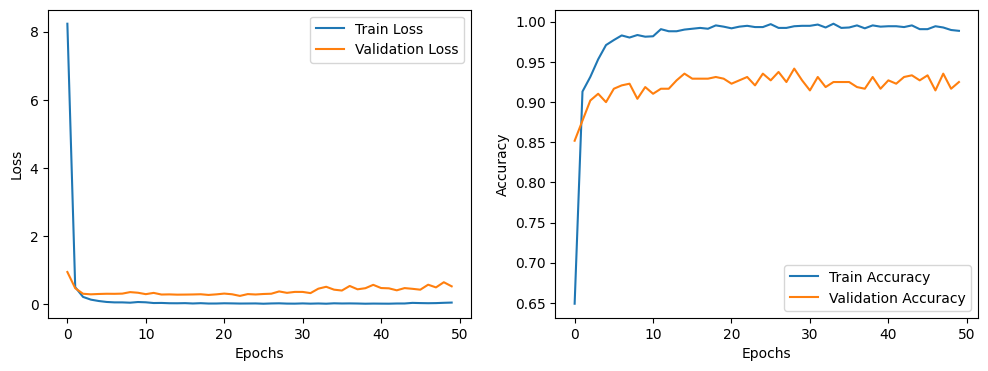

In [30]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_na.history['loss'], label='Train Loss')
plt.plot(history_na.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_na.history['accuracy'], label='Train Accuracy')
plt.plot(history_na.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
# Generate predictions for the test set
predictions_m1 = m1.predict(test_generator)

# Use the true labels directly
y_true_m1 = test_generator.labels

# Convert predicted probabilities to class labels
y_pred_m1 = np.argmax(predictions_m1, axis=1)

# Classification Report
class_report_m1 = classification_report(y_true_m1, y_pred_m1)
print("Classification Report:")
print(class_report_m1)




from sklearn.metrics import accuracy_score

# Calculate the accuracy
accuracy_m1 = accuracy_score(y_true_m1, y_pred_m1)

# Print the accuracy
print("Accuracy:", accuracy_m1)

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 707ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       120
           1       0.99      1.00      1.00       120
           2       1.00      1.00      1.00       128
           3       0.97      0.94      0.95       113
           4       0.99      1.00      1.00       120

    accuracy                           0.98       601
   macro avg       0.98      0.98      0.98       601
weighted avg       0.98      0.98      0.98       601

Accuracy: 0.9816971713810316


# optimizet comiaration

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_a.history['loss'], label='Adam Optimizer')
plt.plot(history_m1_s.history['loss'], label='SGD Optimizer')
plt.plot(history_m1_rs.history['loss'], label='RMSprop Optimizer')
plt.plot(history_na.history['loss'], label='Nadam Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Train Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_a.history['accuracy'], label='Adam Optimizer')
plt.plot(history_m1_s.history['accuracy'], label='SGD Optimizer')
plt.plot(history_m1_rs.history['accuracy'],  label='RMSprop Optimizer')
plt.plot(history_na.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Train Accuracy')
plt.legend()

plt.show()

In [ ]:
 # Visualize training and validation loss and accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_m1_a.history['val_loss'], label='Adam Optimizer')
plt.plot(history_m1_s.history['val_loss'], label='SGD Optimizer')
plt.plot(history_m1_rs.history['val_loss'], label='RMSprop Optimizer')
plt.plot(history_na.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_m1_a.history['val_accuracy'], label='Adam Optimizer')
plt.plot(history_m1_s.history['val_accuracy'], label='SGD Optimizer')
plt.plot(history_m1_rs.history['val_accuracy'],  label='RMSprop Optimizer')
plt.plot(history_na.history['val_accuracy'], label='Nadam Optimizer')
plt.xlabel('Epochs')
plt.ylabel('Validation Accuracy')
plt.legend()

plt.show()